# Fase 2 (paso 1) — Preparación del dataset para YOLOv8-detect

Toma el `dataset/` v4 (formato YOLO OBB, 9 tokens por anotación) y produce `dataset_split/` con:
1. **OBB → AABB** (axis-aligned bounding box): cada cuadrilátero rotado se reemplaza por la caja cuyos lados son los `min`/`max` de los vértices. Es el formato que YOLOv8-detect espera.
2. **Re-particionado 80/10/10** estratificado por clase dominante **y agrupado por imagen base** (`IMG_5XXX`) usando `sklearn.model_selection.GroupShuffleSplit`, para garantizar que las 9 variantes (rotaciones/shear/blur) de cada imagen original queden en un único split — evitando data leakage.

El stretch del resize a 512×512 declarado por Roboflow se **mantiene** (decisión de Fase 2): las augmentations de rotación 90° ya impiden recuperar la orientación original, y las augmentations de entrenamiento (mosaic, mixup, hsv, perspective, shear) compensarán la distorsión. La app móvil aplicará el mismo resize stretch al frame de la cámara antes de inferir.

In [1]:
from __future__ import annotations
import re, shutil
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd
import yaml
from sklearn.model_selection import GroupShuffleSplit

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC  = ROOT / "dataset"
DST  = ROOT / "dataset_split"
REPORTS = ROOT / "reports"; REPORTS.mkdir(exist_ok=True)

with open(SRC / "data.yaml") as f:
    cfg = yaml.safe_load(f)
raw_names = cfg["names"]
ID2NAME = ({int(k): str(v) for k, v in raw_names.items()}
           if isinstance(raw_names, dict)
           else {i: str(n) for i, n in enumerate(raw_names)})
NC = len(ID2NAME)
CLASS_NAMES = [ID2NAME[i] for i in sorted(ID2NAME)]

RNG = 42
BASE_RE = re.compile(r"^(IMG_\d+)")

print(f"Clases: {ID2NAME}")
print(f"DST   : {DST}")

Clases: {0: '100', 1: '1000', 2: '200', 3: '50', 4: '500'}
DST   : /Users/ccepeda/Documents/Personales/Maestria/SistemaRecomendacion/dataset_split


## 1. Conversión OBB → AABB

Cada línea OBB tiene 9 tokens: `class_id  x1 y1 x2 y2 x3 y3 x4 y4` (vértices del cuadrilátero, normalizados en `[0,1]`).

AABB YOLO espera 5 tokens: `class_id  x_center  y_center  w  h`. Las coordenadas se acotan al rango `[0,1]` por seguridad.

In [2]:
def obb_line_to_aabb(line: str) -> str | None:
    t = line.strip().split()
    if not t:
        return None
    if len(t) == 5:
        return line.strip()  # ya es AABB, se conserva
    if len(t) == 9:
        cid = t[0]
        coords = np.array(list(map(float, t[1:])), dtype=float).reshape(4, 2)
        coords = np.clip(coords, 0.0, 1.0)
        x_min, y_min = coords[:, 0].min(), coords[:, 1].min()
        x_max, y_max = coords[:, 0].max(), coords[:, 1].max()
        xc = (x_min + x_max) / 2
        yc = (y_min + y_max) / 2
        w  = max(x_max - x_min, 1e-6)
        h  = max(y_max - y_min, 1e-6)
        return f"{cid} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}"
    return None

def convert_label(src_path: Path) -> tuple[list[str], int]:
    """Devuelve (líneas AABB, número de OBB convertidos)."""
    if not src_path.exists():
        return [], 0
    out, n_conv = [], 0
    for raw in src_path.read_text().splitlines():
        if not raw.strip():
            continue
        bbox = obb_line_to_aabb(raw)
        if bbox is None:
            continue
        out.append(bbox)
        if len(raw.strip().split()) == 9:
            n_conv += 1
    return out, n_conv

## 2. Construcción del pool combinado

Mezclamos las 214 imágenes de los tres splits originales en un único pool y le asignamos a cada imagen:
- `base`: ID base (ej. `IMG_5853`) extraído del filename, para mantener juntas las variantes en el split.
- `dominant_cls`: la clase más frecuente entre las cajas de la imagen, usada como objetivo de estratificación.

In [3]:
def base_id(stem: str) -> str:
    m = BASE_RE.match(stem)
    return m.group(1) if m else stem

rows = []
for split in ["train", "valid", "test"]:
    for img in sorted((SRC / split / "images").iterdir()):
        if img.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        lbl_path = SRC / split / "labels" / (img.stem + ".txt")
        aabb_lines, n_conv = convert_label(lbl_path)
        cls_ids = [int(line.split()[0]) for line in aabb_lines]
        if not cls_ids:
            continue
        rows.append({
            "orig_split": split,
            "image_path": str(img),
            "image_name": img.name,
            "stem": img.stem,
            "base": base_id(img.stem),
            "n_boxes": len(cls_ids),
            "n_obb_converted": n_conv,
            "dominant_cls": Counter(cls_ids).most_common(1)[0][0],
            "aabb_lines": aabb_lines,
        })

pool = pd.DataFrame(rows)
print(f"Imágenes con cajas: {len(pool)}")
print(f"Bases únicos:        {pool['base'].nunique()}")
print(f"Total OBB convertidos: {pool['n_obb_converted'].sum()}")
print("\nVariantes por base:")
print(pool['base'].value_counts().describe().round(2))

Imágenes con cajas: 214
Bases únicos:        38
Total OBB convertidos: 574

Variantes por base:
count    38.00
mean      5.63
std       4.00
min       1.00
25%       1.00
50%       9.00
75%       9.00
max       9.00
Name: count, dtype: float64


## 3. Re-split 80/10/10 estratificado por clase dominante y agrupado por base

`GroupShuffleSplit` garantiza que todas las imágenes con el mismo `base` queden en el MISMO split. La estratificación pura por clase no es trivialmente compatible con grouping, pero podemos aproximarla agregando primero por base (clase dominante mayoritaria del grupo) y luego haciendo `StratifiedGroupKFold`-equivalente con dos pasos de `GroupShuffleSplit`.

Aquí usamos un enfoque simple en dos pasos: 1) separar 20% para holdout, 2) dividir holdout 50/50 en valid/test. La aleatoriedad con seed=42 garantiza reproducibilidad.

In [4]:
# Preservamos el split ORIGINAL de Roboflow (198 train / 8 valid / 8 test).
# Razón: con solo 38 escenas únicas, intentar re-particionar resta volumen
# de entrenamiento y desestabiliza el aprendizaje (verificado experimentalmente).
# Aceptamos que valid/test son pequeños y completamos la evaluación con
# inferencia visual sobre las imágenes de test.

pool["split"] = pool["orig_split"]

print("Tamaño por split (manteniendo original Roboflow):")
print(pool["split"].value_counts())
print("\nBases por split (puede haber bases compartidas — Roboflow lo permitió):")
print(pool.groupby("split")["base"].nunique())

# Verificación de leakage por base
split_per_base = pool.groupby("base")["split"].nunique()
leaked = split_per_base[split_per_base > 1]
if len(leaked):
    print(f"\n⚠️  {len(leaked)} bases compartidas entre splits (data leakage):")
    for b in leaked.index[:10]:
        s = pool[pool["base"] == b]["split"].value_counts().to_dict()
        print(f"  {b}: {s}")
else:
    print("\n✅ Sin leakage — cada base en un solo split.")


Tamaño por split (manteniendo original Roboflow):
split
train    198
valid      8
test       8
Name: count, dtype: int64

Bases por split (puede haber bases compartidas — Roboflow lo permitió):
split
test      8
train    22
valid     8
Name: base, dtype: int64

✅ Sin leakage — cada base en un solo split.


## 4. Generación de `dataset_split/`

In [5]:
if DST.exists():
    shutil.rmtree(DST)
for split in ["train", "valid", "test"]:
    (DST / split / "images").mkdir(parents=True, exist_ok=True)
    (DST / split / "labels").mkdir(parents=True, exist_ok=True)

for _, r in pool.iterrows():
    s = r["split"]
    shutil.copy2(r["image_path"], DST / s / "images" / r["image_name"])
    lbl_dst = DST / s / "labels" / (r["stem"] + ".txt")
    lbl_dst.write_text("\n".join(r["aabb_lines"]) + "\n")

with open(DST / "data.yaml", "w") as f:
    yaml.safe_dump({
        "path":  str(DST.resolve()),
        "train": "train/images",
        "val":   "valid/images",
        "test":  "test/images",
        "nc":    NC,
        "names": CLASS_NAMES,
    }, f, sort_keys=False)

print((DST / "data.yaml").read_text())

path: /Users/ccepeda/Documents/Personales/Maestria/SistemaRecomendacion/dataset_split
train: train/images
val: valid/images
test: test/images
nc: 5
names:
- '100'
- '1000'
- '200'
- '50'
- '500'



## 5. Verificación: distribución de clases por split (a nivel de cajas)

In [6]:
summary_rows = []
for split in ["train", "valid", "test"]:
    n_imgs = 0
    cls_counts = Counter()
    for lbl in (DST / split / "labels").iterdir():
        n_imgs += 1
        for line in lbl.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) == 5:
                cls_counts[int(parts[0])] += 1
    row = {"split": split, "images": n_imgs, "total_boxes": sum(cls_counts.values())}
    for cid in sorted(ID2NAME):
        row[ID2NAME[cid]] = cls_counts.get(cid, 0)
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows).set_index("split")
summary.to_csv(REPORTS / "split_summary.csv")
print(summary)

       images  total_boxes  100  1000  200  50  500
split                                              
train     198          558  135    99  108  72  144
valid       8            8    3     1    1   1    2
test        8            8    1     1    2   2    2


## 6. Visualización de muestras del nuevo split (con cajas AABB)

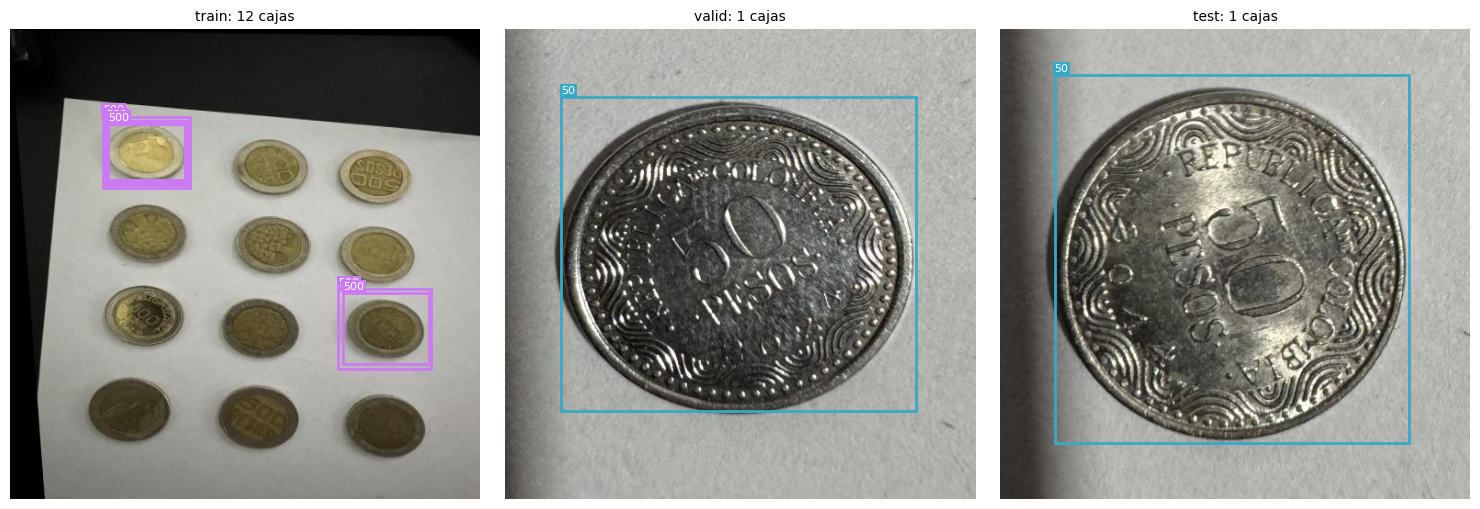

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image

PALETTE = sns.color_palette("husl", NC)

def parse_aabb(p: Path) -> list[tuple[int, float, float, float, float]]:
    out = []
    if not p.exists(): return out
    for line in p.read_text().splitlines():
        t = line.strip().split()
        if len(t) == 5:
            out.append((int(t[0]), *map(float, t[1:])))
    return out

def draw(ax, img_path: Path, boxes, title: str):
    img = np.array(Image.open(img_path).convert("RGB"))
    H, W = img.shape[:2]
    ax.imshow(img)
    for cid, xc, yc, w, h in boxes:
        x = (xc - w / 2) * W; y = (yc - h / 2) * H
        bw, bh = w * W, h * H
        color = PALETTE[cid % NC]
        ax.add_patch(patches.Rectangle((x, y), bw, bh, lw=2, edgecolor=color, facecolor="none"))
        ax.text(x, max(y - 4, 0), ID2NAME[cid], color="white", fontsize=8,
                bbox=dict(facecolor=color, edgecolor="none", pad=1.2))
    ax.set_title(title, fontsize=10); ax.axis("off")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, split in zip(axes, ["train", "valid", "test"]):
    counts_per_img = {}
    for lbl in (DST / split / "labels").iterdir():
        counts_per_img[lbl.stem] = sum(1 for line in lbl.read_text().splitlines() if line.strip())
    if not counts_per_img:
        ax.set_axis_off(); continue
    stem = max(counts_per_img, key=counts_per_img.get)  # imagen con más cajas
    img_path = next((DST / split / "images").glob(f"{stem}.*"))
    boxes = parse_aabb(DST / split / "labels" / (stem + ".txt"))
    draw(ax, img_path, boxes, f"{split}: {len(boxes)} cajas")
plt.tight_layout()
plt.savefig(REPORTS / "split_samples.png", dpi=130)
plt.show()